In [12]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [13]:
data={
    'Customer': ['Anuj','Anij','Aastha','Asmita','Riya'],
    'Age': [20,19,25,25,18],
    'Spending':[100,60,500,400,160]
}

df=pd.DataFrame(data)
df

,Customer,Age,Spending
0,Anuj,20,100
1,Anij,19,60
2,Aastha,25,500
3,Asmita,25,400
4,Riya,18,160


c:\Users\anujs\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


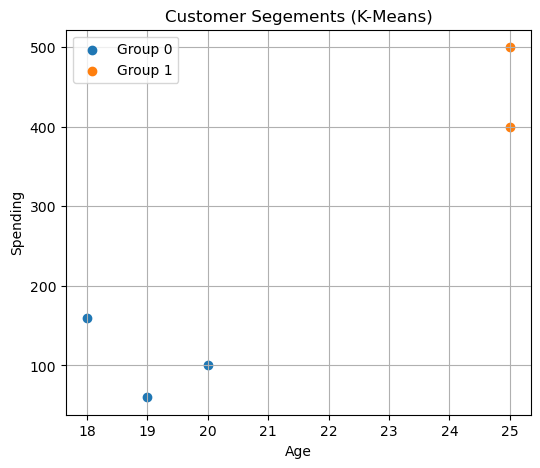

  Customer  Age  Spending  Group
0     Anuj   20       100      0
1     Anij   19        60      0
2   Aastha   25       500      1
3   Asmita   25       400      1
4     Riya   18       160      0


In [14]:
X=df[['Age','Spending']]

model=KMeans(n_clusters=2,random_state=42,n_init=10)

df["Group"]=model.fit_predict(X)

plt.figure(figsize=(6,5))
for group in df['Group'].unique(): #[0,1]
    group_data=df[df['Group']==group]
    plt.scatter(group_data['Age'],group_data['Spending'],label=f'Group {group}')

plt.xlabel("Age")
plt.ylabel("Spending")
plt.title("Customer Segements (K-Means)")
plt.legend()
plt.grid(True)
plt.show()

print(df)

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

In [18]:
data={
    'Age': [25,30,35,40,45,50],
    'Income': [30000,40000,50000,60000,70000,80000],
    'Spending': [70,60,50,40,30,20],
    'Savings': [1000,5000,8000,10000,15000,20000] 
}

df=pd.DataFrame(data)
df

,Age,Income,Spending,Savings
0,25,30000,70,1000
1,30,40000,60,5000
2,35,50000,50,8000
3,40,60000,40,10000
4,45,70000,30,15000
5,50,80000,20,20000


In [19]:
scalar=StandardScaler()
scaled_data=scalar.fit_transform(df)
scaled_data

array([[-1.46385011, -1.46385011,  1.46385011, -1.41195343],
       [-0.87831007, -0.87831007,  0.87831007, -0.77257829],
       [-0.29277002, -0.29277002,  0.29277002, -0.29304694],
       [ 0.29277002,  0.29277002, -0.29277002,  0.02664063],
       [ 0.87831007,  0.87831007, -0.87831007,  0.82585955],
       [ 1.46385011,  1.46385011, -1.46385011,  1.62507848]])

Variance captured by each PCA Component:
[99.65  0.35]


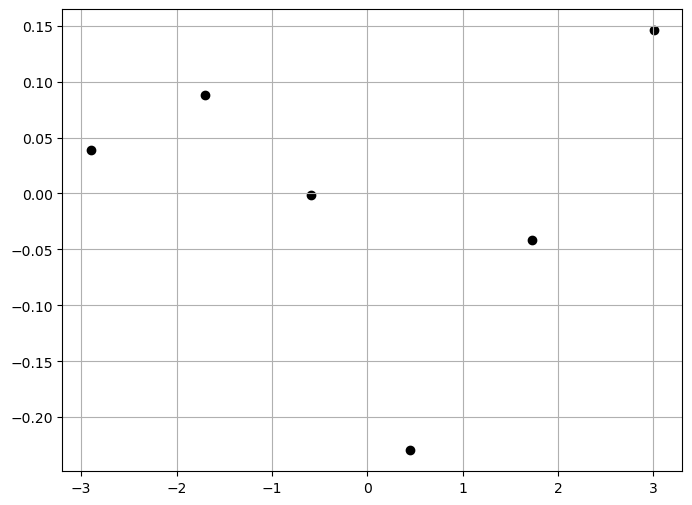

       PCA1      PCA2
0 -2.901838  0.038962
1 -1.703939  0.088054
2 -0.585677 -0.001447
3  0.452949 -0.229542
4  1.730485 -0.041856
5  3.008020  0.145829


In [22]:
pca=PCA(n_components=2)
pca_result=pca.fit_transform(scaled_data)

pca_df=pd.DataFrame(pca_result,columns=['PCA1','PCA2'])
explainedVariance=pca.explained_variance_ratio_
print("Variance captured by each PCA Component:")
print(np.round(explainedVariance*100,2))

plt.figure(figsize=(8,6))
plt.scatter(pca_df['PCA1'],pca_df['PCA2'],color='black')
plt.grid(True)
plt.show()

print(pca_df)